In [1]:
# First we do a set of imports
import csv
from pprint import pprint
import cinnabar
from cinnabar import plotting as cinnabar_plotting
from cinnabar import femap, stats

# Loading experimental data
First we load our known experimental data from a csv file.

The format of the CSV file is as follows:
```
Ligand,Exp-dG
FXR_78,-10.3
FXR_12,-9.9
···
Since most experimental data do not provide error information, a fixed experimental error is manually set. 
The binding free energy (dG) is calculated using the formula dG = -RT lnKa = RT lnKd. At room temperature (25°C), taking IC50 as an example, we have: dG = RT lnIC50 = 0.592 × lnIC50.

In [2]:
def read_exp_dg(file, ddG=0.2):
    """
    读取实验数据文件 (CSV)，包含 Ligand 和 Exp-dG 列，
    添加 ddG 误差列（固定值），返回字典。

    参数:
        file (str): CSV 文件路径，如 'fxr-exp.csv'
        ddG (float): dG 的误差值，默认为 0.2

    返回:
        dict: {ligand: {'dG': float, 'ddG': float}}
    """
    experimental_data = {}

    with open(file, 'r', newline='', encoding='utf-8') as csvfile:
        reader = csv.DictReader(csvfile)

        # 检查必需列是否存在
        required_columns = {'Ligand', 'Exp-dG'}
        if not required_columns.issubset(reader.fieldnames):
            raise ValueError(f"CSV 文件必须包含列：{required_columns}，当前列：{set(reader.fieldnames)}")

        for row in reader:
            ligand = row['Ligand'].strip() # 去除空格
            try:
                dG = float(row['Exp-dG'])
            except ValueError:
                print(f"警告：无法将 Exp-dG '{row['Exp-dG']}' 转换为浮点数，跳过该行。")
                continue

            experimental_data[ligand] = {
                'dG': dG,
                'ddG': ddG # 固定误差值
            }

    return experimental_data

In [3]:
experimental_data = read_exp_dg('fxr_exp.csv')

In [4]:
print(experimental_data)

{'FXR_78': {'dG': -10.3, 'ddG': 0.2}, 'FXR_12': {'dG': -9.9, 'ddG': 0.2}, 'FXR_82': {'dG': -9.2, 'ddG': 0.2}, 'FXR_77': {'dG': -9.0, 'ddG': 0.2}, 'FXR_85': {'dG': -8.9, 'ddG': 0.2}, 'FXR_83': {'dG': -8.8, 'ddG': 0.2}, 'FXR_88': {'dG': -8.6, 'ddG': 0.2}, 'FXR_74': {'dG': -8.4, 'ddG': 0.2}, 'FXR_89': {'dG': -8.4, 'ddG': 0.2}, 'FXR_81': {'dG': -7.6, 'ddG': 0.2}, 'FXR_84': {'dG': -7.3, 'ddG': 0.2}, 'FXR_79': {'dG': -7.3, 'ddG': 0.2}, 'FXR_10': {'dG': -7.2, 'ddG': 0.2}, 'FXR_76': {'dG': -6.0, 'ddG': 0.2}}


# Loading free energy results
First, use the `openfe gather` command to export the RBFE calculation results:
```
openfe gather --report ddg ./results -o fxr_openfe_rbfe_results.tsv --tsv
```

In [5]:
# Read in calculated results

calculated_data = {}
calculated_filename = 'fxr_openfe_rbfe_results.tsv'

with open(calculated_filename, 'r') as fd:
    rd = csv.reader(fd, delimiter="\t", quotechar='"')
    headers = next(rd)
    for row in rd:
        tag = row[0] + "->" + row[1]
        calculated_data[tag] = {}
        calculated_data[tag]['ligand_i'] = row[0]
        calculated_data[tag]['ligand_j'] = row[1]
        calculated_data[tag]['dG'] = float(row[2])
        calculated_data[tag]['ddG'] = float(row[3])

pprint(calculated_data)

{'FXR_12->FXR_10': {'dG': 2.0,
                    'ddG': 0.04,
                    'ligand_i': 'FXR_12',
                    'ligand_j': 'FXR_10'},
 'FXR_12->FXR_74': {'dG': -0.308,
                    'ddG': 0.009,
                    'ligand_i': 'FXR_12',
                    'ligand_j': 'FXR_74'},
 'FXR_12->FXR_76': {'dG': 1.5,
                    'ddG': 0.2,
                    'ligand_i': 'FXR_12',
                    'ligand_j': 'FXR_76'},
 'FXR_12->FXR_77': {'dG': -1.4,
                    'ddG': 0.2,
                    'ligand_i': 'FXR_12',
                    'ligand_j': 'FXR_77'},
 'FXR_12->FXR_78': {'dG': -1.5,
                    'ddG': 0.3,
                    'ligand_i': 'FXR_12',
                    'ligand_j': 'FXR_78'},
 'FXR_12->FXR_79': {'dG': 3.0,
                    'ddG': 1.0,
                    'ligand_i': 'FXR_12',
                    'ligand_j': 'FXR_79'},
 'FXR_12->FXR_81': {'dG': -1.2,
                    'ddG': 0.1,
                    'ligand_i': 'FXR_12'

# Creating a Cinnabar CSV file
Next we take the data we’ve gathered above and write it out as cinnabar “csv” file.

In [6]:
cinnabar_filename = 'cinnabar_input.csv'

with open(cinnabar_filename, 'w') as f:
    f.write("# Experimental block\n")
    f.write("# Ligand, expt_DDG, expt_dDDG\n")
    for entry in experimental_data:
        dG = experimental_data[entry]['dG']
        ddG = experimental_data[entry]['ddG']
        f.write(f"{entry},{dG:.2f},{ddG:.2f}\n")
    f.write('\n')
    f.write('# Calculated block\n')
    f.write('# Ligand1,Ligand2,calc_DDG,calc_dDDG(MBAR),calc_dDDG(additional)\n')
    for entry in calculated_data:
        dG = calculated_data[entry]['dG']
        ddG = calculated_data[entry]['ddG']
        molA = calculated_data[entry]['ligand_i']
        molB = calculated_data[entry]['ligand_j']
        f.write(f"{molA},{molB},{dG:.2f},0,{ddG:.2f}\n")

# Plotting the results using Cinnabar
Once we’ve created the appropriate Cinnabar input file we can go ahead and plot out our results.

## Generating a Cinnabar FEMap and plotting out the network
First let’s load the data into cinnabar and draw out the network of free energy results.

/public/gkxiao/software/miniforge3/envs/openfe_env/lib/python3.13/site-packages/cinnabar/femap.py:43: UserWarning: Assuming kcal/mol units on measurements
  warnings.warn("Assuming kcal/mol units on measurements")


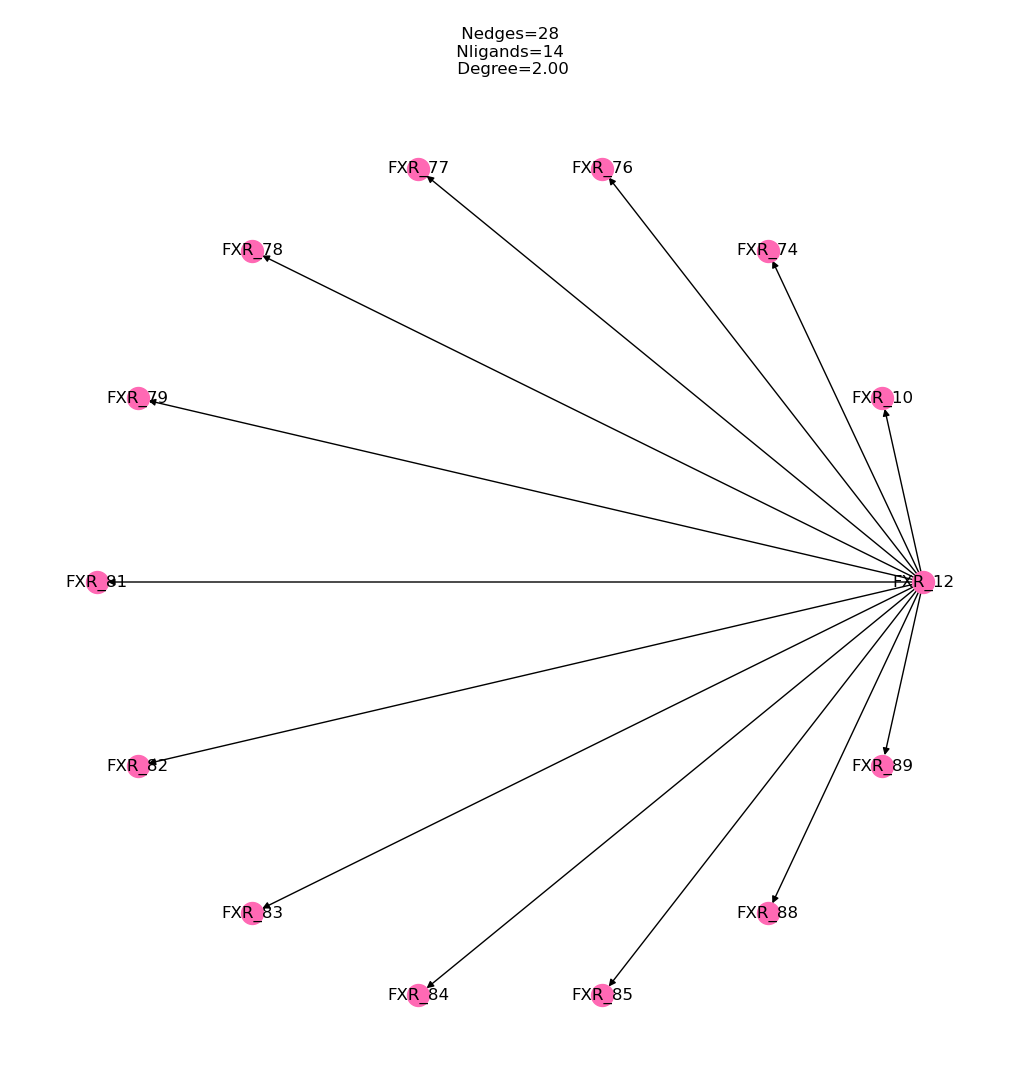

In [7]:
fe = femap.FEMap.from_csv('cinnabar_input.csv')
fe.generate_absolute_values()  # Get MLE generated estimates of the absolute values
fe.draw_graph()

# Plotting out the relative free energy results
Next we can go ahead and plot out the relative free energy results.

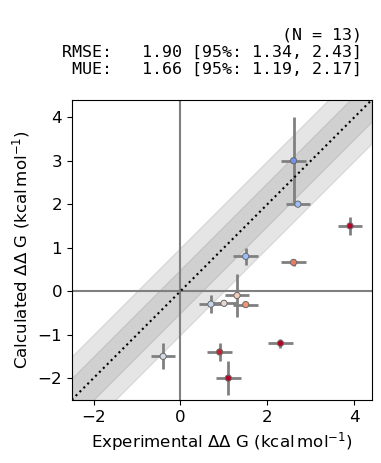

In [8]:
# note you can pass the filename argument to write things out to file
cinnabar_plotting.plot_DDGs(fe.to_legacy_graph(), figsize=5)

# Plotting out the absolute free energy results
Finally let’s go ahead and plot out the MLE derived absolute free energies

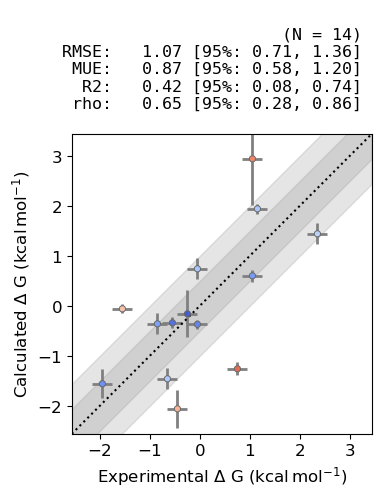

In [9]:
# note you can pass the filename argument to write to file
cinnabar_plotting.plot_DGs(fe.to_legacy_graph(), figsize=5)

We can also shift our free energies by the average experimental value to have DGs on the same scale as experiment.

/public/gkxiao/software/miniforge3/envs/openfe_env/lib/python3.13/site-packages/cinnabar/femap.py:43: UserWarning: Assuming kcal/mol units on measurements
  warnings.warn("Assuming kcal/mol units on measurements")


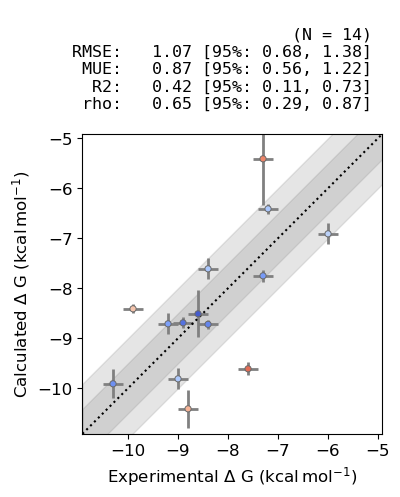

In [10]:
data = femap.read_csv('cinnabar_input.csv')
exp_DG_sum = sum([data['Experimental'][i].DG for i in data['Experimental'].keys()])
shift = exp_DG_sum / len(data['Experimental'].keys())

cinnabar_plotting.plot_DGs(fe.to_legacy_graph(), figsize=5,  shift=shift.m)

# Writing out the MLE derived absolute free energies
Finally, we can also write out the MLE derived absolute free energies in the following manner.

Note: you can obtain this directly from your results by calling ``openfe gather –report dg``

In [11]:
dG_results = {}
nodes = list(fe.to_legacy_graph().nodes.data())

for key in range(len(nodes)):
    dG_results[nodes[key][0]] = {
        'experimental_estimate': nodes[key][1]['exp_DG'],
        'experimental_error': nodes[key][1]['exp_dDG'],
        'calculated_estimate': round(nodes[key][1]['calc_DG'],2),
        'calculated_error': round(nodes[key][1]['calc_dDG'],2),
    }

# We can now print out the results
pprint(dG_results)

# write out the calculated results
with open('dG_calculated_results.dat', 'w') as f:
    writer = csv.writer(f, delimiter="\t", lineterminator="\n")
    writer.writerow(["ligand", "DG(MLE)", "uncertainty (kcal/mol)",])
    for ligand in dG_results:
        writer.writerow([
            ligand,
            dG_results[ligand]['calculated_estimate'],
            dG_results[ligand]['calculated_error'],
        ])

# write out the experimental results
with open('dG_experimental_results.dat', 'w') as f:
    writer = csv.writer(f, delimiter="\t", lineterminator="\n")
    writer.writerow(["ligand", "DG", "uncertainty (kcal/mol)",])
    for ligand in dG_results:
        writer.writerow([
            ligand,
            dG_results[ligand]['experimental_estimate'],
            dG_results[ligand]['experimental_error'],
        ])

{'FXR_10': {'calculated_error': np.float64(0.1),
            'calculated_estimate': np.float64(1.94),
            'experimental_error': 0.2,
            'experimental_estimate': -7.2},
 'FXR_12': {'calculated_error': np.float64(0.09),
            'calculated_estimate': np.float64(-0.06),
            'experimental_error': 0.2,
            'experimental_estimate': -9.9},
 'FXR_74': {'calculated_error': np.float64(0.09),
            'calculated_estimate': np.float64(-0.37),
            'experimental_error': 0.2,
            'experimental_estimate': -8.4},
 'FXR_76': {'calculated_error': np.float64(0.21),
            'calculated_estimate': np.float64(1.44),
            'experimental_error': 0.2,
            'experimental_estimate': -6.0},
 'FXR_77': {'calculated_error': np.float64(0.21),
            'calculated_estimate': np.float64(-1.46),
            'experimental_error': 0.2,
            'experimental_estimate': -9.0},
 'FXR_78': {'calculated_error': np.float64(0.29),
            'calcu